# Chapter 6 — Bridge: From Daily Bars to Intraday Data

Chapters 1–5 lived entirely in daily-bar space. Every chapter from this point forward operates intraday: minute bars, sub-session holding periods, regime context that varies *within* a single trading day. This chapter crosses that boundary cleanly, so subsequent chapters can assume you have working intraday data, know how time-of-day shapes returns, and understand how minute bars differ from daily bars in structurally important ways.

It is the first chapter that's not about *measurement* — it's about practice. There is almost no new statistical machinery; the math budget is intentionally near-zero. The work is in tooling, intuition, and one or two pictures that are pedagogically irreversible — once you've seen the U-shape, you can never go back to thinking returns are i.i.d. across a session.

## Three things change going from daily to intraday

1. **Time has a clock.** Returns are not exchangeable across the session. A 9:32 ET return is drawn from a different distribution than a 12:04 ET return. Vol per minute follows a roughly U-shaped pattern across the day. (§4.)
2. **The bar isn't given to you.** On daily timeframes the close is a natural sampling boundary — the market shuts at 4 PM and reopens at 9:30 AM. Intraday, *you* choose how to slice the data: every minute, every fixed number of shares, every fixed dollar volume, every unit of order-flow imbalance. Different choices, different statistical properties. (§3.)
3. **External events punch through the seasonality.** At 14:00 ET on a scheduled FOMC announcement day, vol jumps several-fold regardless of where in the U-shape you are. Same for CPI prints (8:30 ET pre-market) and Non-Farm Payrolls (8:30 ET pre-market). (§5.)

Each of those is one section of this chapter.

## §1 — Why intraday data is different

Chapter 1 said i.i.d. returns are an idealization the rest of the curriculum keeps pushing back on. Daily-bar returns aren't i.i.d. — Chapter 2 showed vol clustering and fat tails. Intraday data violates i.i.d. in a *different* way that's easier to see and harder to unsee: returns are not exchangeable across the session, because time itself has structure. The 9:32 ET minute is a different beast from the 12:04 ET minute.

Every measurement we built in Chapters 1-5 — vol, VaR, Sharpe — assumed a return distribution that was at least *stationary in time*. That assumption gets ripped up here. Going forward, "stationary" needs a session-time qualifier.

## §2 — Where the data comes from: Alpaca free-tier setup

Daily SPY bars from Yahoo Finance got us through Chapters 1–5 because they're free, no signup, and a lifetime of history is one HTTP request away. Intraday data is harder. Free vendors with multi-year minute-bar history are scarce; most charge.

This curriculum uses **Alpaca Markets** (https://alpaca.markets) free tier. Alpaca is a US brokerage with a Trading API; opening a *paper-trading* account is free, takes a few minutes, and gives you bundled access to historical IEX-feed minute bars with multi-year depth. We never place a real trade in this curriculum until Ch18; the paper account is just a credentialed gateway to data.

> **Two Alpaca products — pick the right one.** Alpaca offers a **Trading API** (for individual traders) and a **Broker API** (for businesses building a brokerage app on Alpaca's infrastructure). You want the Trading API. The Market Data API is bundled with it, no separate signup needed.

> **Non-US-resident note.** Alpaca account creation may not be available in all jurisdictions. If you can't sign up, the chapter is still valuable for the conceptual content; for hands-on, the same code works against any minute-bar source you can substitute (Polygon free tier, Databento community sample, archived broker tape) — only the data-loading function changes.

### Setup steps

1. Sign up at https://alpaca.markets and verify the account.
2. From the dashboard, generate **paper-trading** API keys. You'll get an `APCA_API_KEY_ID` (~26 chars) and an `APCA_API_SECRET_KEY` (~44 chars).
3. Copy `.env.example` from the repo root to `.env` and paste your keys:
   ```
   APCA_API_KEY_ID=PKxxxxxxxxxxxxxxxxxx
   APCA_API_SECRET_KEY=yyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyyy
   ```
   `.env` is listed in `.gitignore`. **Never commit it.**
4. Install the SDK and parquet engine — already in `requirements.txt`:
   ```bash
   uv pip install -r requirements.txt
   ```
   New for this chapter: `alpaca-py`, `pyarrow`, `python-dotenv`.

### The pull script

Pull one year of 1-minute bars for QQQ (primary) and SPY (Exercise 1) and cache them locally as parquet. The cache is in `06-bridge-to-intraday/data/`, gitignored — re-fetch any time. Save the script as `pull_data.py` in the chapter folder, or just paste into a shell:

```python
import os
from datetime import datetime, timedelta, timezone
from pathlib import Path
from dotenv import load_dotenv
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockBarsRequest
from alpaca.data.timeframe import TimeFrame

load_dotenv()
client = StockHistoricalDataClient(
    os.environ["APCA_API_KEY_ID"], os.environ["APCA_API_SECRET_KEY"]
)
end = datetime.now(timezone.utc).replace(hour=0, minute=0, second=0, microsecond=0)
start = end - timedelta(days=365)

DATA = Path("data")
DATA.mkdir(exist_ok=True)

for sym in ["QQQ", "SPY"]:
    req = StockBarsRequest(
        symbol_or_symbols=[sym],
        timeframe=TimeFrame.Minute,
        start=start,
        end=end,
        feed="iex",
    )
    bars = client.get_stock_bars(req).df
    bars = bars.reset_index(level=0, drop=True)
    bars.index.name = "ts_utc"
    bars.to_parquet(DATA / f"{sym.lower()}_1min.parquet")
    print(f"{sym}: {len(bars):,} rows")
```

> The `data/` directory is gitignored repo-wide, so a fresh clone won't have it. The script creates the folder on first run via `DATA.mkdir(exist_ok=True)`. Subsequent runs reuse the cache.

Expected output: ~100k rows per symbol over a year (24h-coverage bars; we filter to RTH later). Two parquet files in `data/`, ~5 MB each.

### Why we cache locally as parquet

Three reasons:

1. **Iteration speed.** The notebook re-runs in seconds against a parquet read, vs minutes against a fresh API call. You'll edit and re-run the notebook many times.
2. **Reproducibility.** Alpaca's IEX feed *can* change — backfill corrections happen. Snapshot once, work against the snapshot, refresh deliberately.
3. **Rate limits.** Free tier has them; if you re-pull every notebook run you'll hit caps quickly during a working session.

Parquet (via `pyarrow`) is the format of choice for time-series like this — columnar, compressed, with type fidelity for the timestamp index.

### Loading the cached QQQ minute bars

From here on we work entirely against the cached parquet — no live API calls in the notebook. If `data/qqq_1min.parquet` is missing, run the pull script above to regenerate it.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA = Path("data")
qqq = pd.read_parquet(DATA / "qqq_1min.parquet")
# Convert UTC timestamps to NY wall-clock so 9:30 means the open, not 13:30 UTC.
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
print("rows:", f"{len(qqq):,}", " range:", qqq.index.min(), "→", qqq.index.max())
qqq.head()


rows: 101,672  range: 2025-05-08 08:42:00-04:00 → 2026-05-07 16:00:00-04:00


,open,high,low,close,volume,trade_count,vwap
ts_utc,,,,,,,
2025-05-08 08:42:00-04:00,488.47,488.47,488.47,488.47,220.0,3.0,488.470000
2025-05-08 08:44:00-04:00,488.10,488.10,488.10,488.10,100.0,1.0,488.100000
2025-05-08 08:58:00-04:00,488.85,488.85,488.85,488.85,200.0,2.0,488.850000
2025-05-08 09:03:00-04:00,488.79,488.79,488.78,488.78,300.0,4.0,488.785000
2025-05-08 09:30:00-04:00,488.48,488.74,488.17,488.74,4763.0,49.0,488.437834


### One thing to internalize about IEX-feed data

These bars came from Alpaca's free-tier IEX feed. **IEX is *one* exchange among many.** A "minute bar" from IEX is the OHLCV of trades that printed on IEX during that minute. Minutes when IEX itself had no prints — even if other venues did — produce no bar. We'll see this clearly in §7 when we audit for gaps.

## §3 — Bar construction: time, volume, dollar, imbalance

The 1-minute bars from Alpaca are **time bars** — every minute of wall-clock time, regardless of how much trading happened in it. Time bars are the workhorse of this curriculum (and most quant work) because they're regular, easy to reason about, and natively supported by every backtest library. But they're not the only choice — and on intraday timeframes the alternatives matter enough to know about.

The four bar types you'll see in the literature, ordered by how widely they're used:

- **Time bars** (this curriculum's default): every N minutes/seconds. Regular cadence, but information density varies wildly across the day — a 1-minute bar at 9:31 ET represents very different amounts of trading than a 1-minute bar at 12:31.
- **Volume bars**: every N shares traded. Equalizes information density by share count.
- **Dollar bars**: every $N of notional traded. Equalizes further (handles price changes over time, so a bar from 2010 and a bar from 2026 represent comparable amounts of *capital* changing hands).
- **Imbalance bars**: every N units of signed order-flow imbalance (buys minus sells). Equalizes by *information arrival* in a microstructural sense. Most exotic; needs trade-direction inference (Lee-Ready or similar) when the data only tells you "a trade happened" without saying buyer- or seller-initiated.

In §6 of the notebook we build dollar bars for one trading day on QQQ and compare bar-counts-per-hour against the constant 60-per-hour you'd get from minute bars. Time bars give you the same number per hour by construction; dollar bars cluster where the activity is — relatively few during midday, *many* at the close.

This curriculum uses time bars exclusively through Ch15. Dollar bars resurface in Ch13 (microstructure & execution) when slippage modeling needs information-equalized samples. Volume bars and imbalance bars are named here only — for the canonical treatment, see López de Prado, *Advances in Financial Machine Learning* (Wiley, 2018), Chapter 2.

### Filtering to Regular Trading Hours

Alpaca returns 24-hour bars (pre-market and after-hours included). Most strategies in this curriculum operate Regular Trading Hours only — 9:30 AM to 4:00 PM ET. We filter and add a `minute_of_session` column (0 at the open, 389 at the close).

In [2]:
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute  # minutes since midnight ET
RTH_OPEN = 9 * 60 + 30
RTH_CLOSE = 16 * 60
# Keep only bars during regular trading hours (drops pre-market and after-hours).
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN  # 0 at open, 389 at last RTH minute
rth["session_date"] = rth.index.normalize()  # midnight-ET date — used to group bars by session
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))  # bar-to-bar log return
# Zero out the first bar of each session (no overnight return at intraday level)
session_first = rth.groupby("session_date").head(1).index
rth.loc[session_first, "log_ret"] = np.nan
print(f"RTH bars: {len(rth):,}  sessions: {rth['session_date'].nunique()}")


RTH bars: 95,318  sessions: 251


## §4 — Intraday seasonality: the U-shape

The chapter's empirical hook. For each minute of the trading session — minute 0 = 9:30 ET, minute 389 = 15:59 ET — compute the mean absolute log return across all sessions in the data window, then plot. The notebook does this in two cells (one to compute, one to plot).

The numbers you should see on QQQ for a one-year window:

| Window | Mean \|return\| | Ratio to midday |
|---|---|---|
| Open: minutes 1–5 (9:31–9:35) | ~5.96 bp | 2.27× |
| Midday: minutes 180–184 (12:30–12:34) | ~2.63 bp | 1.00× |
| Close: minutes 385–389 (15:55–15:59) | ~3.08 bp | 1.17× |

(*bp = basis points = 0.01% per minute. Numbers will shift if you re-pull a different window.*)

### Computing the U-shape

For each minute of the session (0 to 389), compute the mean absolute log return across all sessions, then plot.

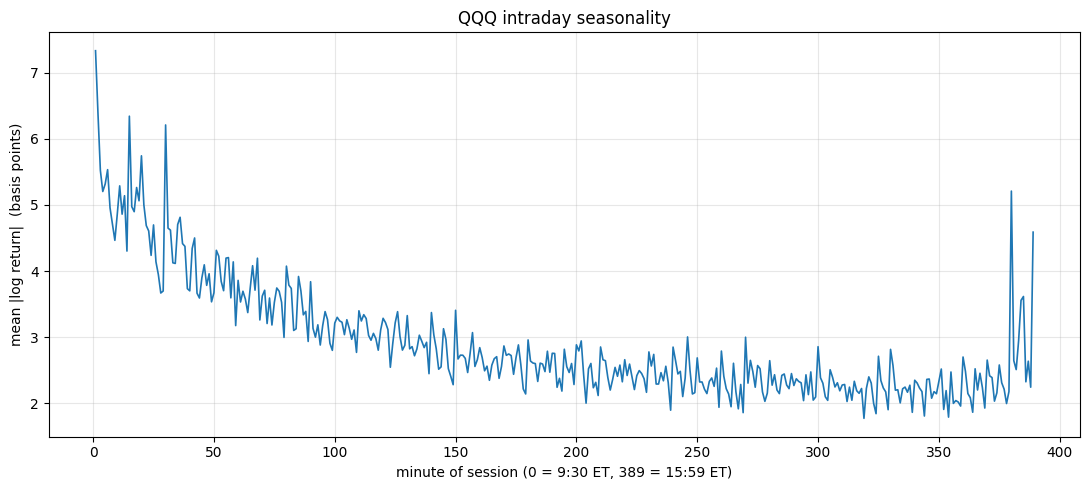

In [3]:
# For each minute-of-session, average |log return| across all sessions in the sample.
ushape = (
    rth.dropna(subset=["log_ret"])
       .groupby("minute_of_session")["log_ret"]
       .apply(lambda s: s.abs().mean())
)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ushape.index, ushape.values * 1e4, lw=1.2)  # scale to basis points (1 bp = 1e-4)
ax.set_xlabel("minute of session (0 = 9:30 ET, 389 = 15:59 ET)")
ax.set_ylabel("mean |log return|  (basis points)")
ax.set_title("QQQ intraday seasonality")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The numbers behind the picture:

In [4]:
open5 = ushape.loc[1:5].mean()
mid5  = ushape.loc[180:184].mean()
close5 = ushape.loc[385:389].mean()
print(f"open  5min mean |r|: {open5*1e4:.2f} bp")
print(f"mid   5min mean |r|: {mid5*1e4:.2f} bp")
print(f"close 5min mean |r|: {close5*1e4:.2f} bp")
print(f"open/mid:  {open5/mid5:.2f}×")
print(f"close/mid: {close5/mid5:.2f}×")


open  5min mean |r|: 5.96 bp
mid   5min mean |r|: 2.63 bp
close 5min mean |r|: 3.08 bp
open/mid:  2.27×
close/mid: 1.17×


**What this picture says — and what it doesn't.** The textbook story you'll read in older microstructure papers is that intraday vol is U-shaped: high at the open, calm through midday, *high* at the close. On QQQ in this window, the morning peak is real and clean — about 2.27× the midday baseline — but **the closing bump is barely there in vol terms** (1.17× midday). It's there if you squint, but it's not the dramatic second peak the textbook story promises.

This is where being honest with the data matters. Two possibilities:

1. The classic U-shape was strongest when most trading happened on a single venue (NYSE floor) and intraday infrastructure was different. Modern markets fragment trading across many venues with different intraday rhythms; the aggregate "U" smooths out.
2. The closing burst lives in *activity* (volume, dollar volume) rather than in *return magnitude*. We'll see this clearly in §6 — closing-hour dollar volume is much higher than midday — even though the closing returns themselves aren't dramatically larger than midday returns.

Both are true. The second is the more useful framing for an intraday trader: **vol per return ≠ amount of trading**, and they don't always move together. Strategies that need *liquidity* (large-size execution, thin-spread fills) care about activity. Strategies that need *vol* (mean-reversion thresholds, breakout filters) care about return magnitude. Don't conflate them.

**Decision rule unlocked.** Any strategy that doesn't condition on time-of-day implicitly assumes stationarity that is empirically wrong by 2-3× across a session on QQQ. Sizing thresholds, stop losses, signal-significance tests — all need a session-time component, or they're mis-calibrated. A "1% move" at 9:32 means something very different from a "1% move" at 12:32, even though they're both 1%.

## §5 — Event windows preview

The U-shape isn't the whole story. Some sessions have *additional* structure on top of seasonality, driven by scheduled releases that the entire market knows are coming.

Three to know:

- **FOMC announcements.** The Federal Open Market Committee sets the federal-funds-rate target. Eight scheduled meetings per year, with the press-release announcement at **14:00 ET** (followed by a press conference at 14:30 on alternating meetings). Vol around the announcement minute jumps several-fold.
- **CPI release.** Consumer Price Index — the headline inflation print. Released monthly by the BLS at **08:30 ET**, in the pre-market session. The 8:30 minute and the 9:30 cash open absorb the bulk of the reaction.
- **NFP / Employment Situation.** Non-Farm Payrolls — the headline labor-market print. Also monthly, also 08:30 ET pre-market. Same general pattern as CPI.

The notebook §5 hardcodes the eight FOMC dates that fell in the data window, builds two U-shapes (FOMC days vs all other days), and overlays them. The FOMC line tracks the non-FOMC line through the morning, then explodes at minute 270 (14:00 ET). The headline number on this window:

> **At 14:00 ET on FOMC days, mean |return| is ~12.23 bp vs ~2.73 bp on non-FOMC days — a 4.49× ratio.**

Pedagogically, the takeaway is simple: **the U-shape isn't a complete model of intraday vol.** The day's calendar punches holes through it.

### FOMC dates in this window

The Federal Open Market Committee (FOMC) announces interest-rate decisions at 14:00 ET on roughly 8 scheduled days per year. Hardcode those dates and tag each session as FOMC / non-FOMC.

In [5]:
# FOMC scheduled-meeting dates (announcement at 14:00 ET).
fomc_candidate = [
    "2025-05-07", "2025-06-18", "2025-07-30", "2025-09-17",
    "2025-10-29", "2025-12-10",
    "2026-01-28", "2026-03-18", "2026-04-29",
]
# Localize to NY so equality with session_date (also NY-tz) works without tz mismatch errors.
fomc_dates = pd.to_datetime(fomc_candidate).tz_localize("America/New_York")
window_start, window_end = rth.index.min().normalize(), rth.index.max().normalize()
fomc_dates = fomc_dates[(fomc_dates >= window_start) & (fomc_dates <= window_end)]
fomc_set = set(d.normalize() for d in fomc_dates)
rth["is_fomc"] = rth["session_date"].isin(fomc_set)  # boolean flag broadcast to every bar
print(f"FOMC sessions in window: {len(fomc_set)}")


FOMC sessions in window: 8


Now overlay FOMC-day mean |return| against non-FOMC days, with a vertical line at minute 270 (14:00 ET).

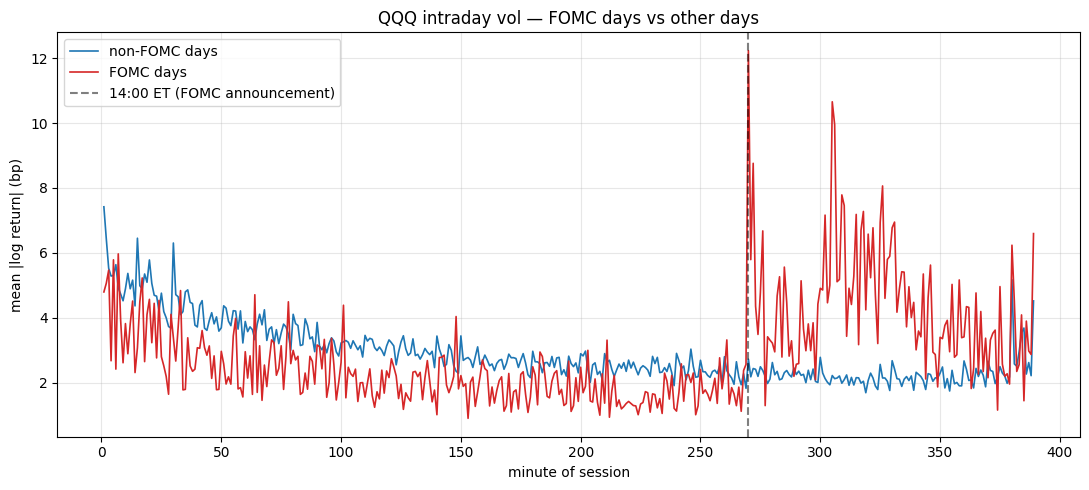

FOMC-day 14:00 |r|: 12.23 bp   non-FOMC: 2.73 bp   ratio: 4.5×


In [6]:
# Same minute-of-session average as §4, but split into FOMC vs non-FOMC sessions.
fomc_ushape = (rth[rth["is_fomc"]].dropna(subset=["log_ret"])
               .groupby("minute_of_session")["log_ret"].apply(lambda s: s.abs().mean()))
non_ushape  = (rth[~rth["is_fomc"]].dropna(subset=["log_ret"])
               .groupby("minute_of_session")["log_ret"].apply(lambda s: s.abs().mean()))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(non_ushape.index, non_ushape.values * 1e4, lw=1.2, label="non-FOMC days")
ax.plot(fomc_ushape.index, fomc_ushape.values * 1e4, lw=1.2, label="FOMC days", color="tab:red")
ax.axvline(270, color="black", linestyle="--", alpha=0.5, label="14:00 ET (FOMC announcement)")  # minute 270 = 14:00
ax.set_xlabel("minute of session")
ax.set_ylabel("mean |log return| (bp)")
ax.set_title("QQQ intraday vol — FOMC days vs other days")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Compare the single 14:00 minute on FOMC vs non-FOMC days — the announcement effect in one number.
fomc_2pm = rth[(rth["minute_of_session"] == 270) & rth["is_fomc"]]["log_ret"].abs().mean()
non_2pm  = rth[(rth["minute_of_session"] == 270) & ~rth["is_fomc"]]["log_ret"].abs().mean()
print(f"FOMC-day 14:00 |r|: {fomc_2pm*1e4:.2f} bp   non-FOMC: {non_2pm*1e4:.2f} bp   ratio: {fomc_2pm/non_2pm:.1f}×")


**Headline.** At 14:00 ET on FOMC days, the average minute-bar moves ~4.5× more than the same minute on a typical day. The U-shape is no longer the right story — the chart has been re-shaped around the announcement window.

**Forward pointer.** Building strategies around scheduled events is its own subject, but the toolkit lives in two later chapters:
- **Ch15** (intraday vol & regime detection) — how to detect that you've entered a high-vol regime, how to vol-target through it, when to flat-line.
- **Ch16** (more strategies) — an event-driven strategy as one of the worked examples.

Ch6's job is just: see that the spike exists.

### Time bars vs dollar bars: a worked example

The bars we've been working with are **time bars** — every minute, regardless of how much trading happened in it. **Dollar bars** sample every fixed amount of notional traded. On a quiet midday minute they sample less often; on a chaotic opening or closing minute they sample more often. Information content per bar is roughly equalized.

Build dollar bars for one trading day, with a threshold chosen so the day produces ~78 bars (matching what you'd get from 5-minute time bars on a full session).

reference day: 2025-09-18
total dollar volume: $496,002,076
threshold per bar: $6,359,001


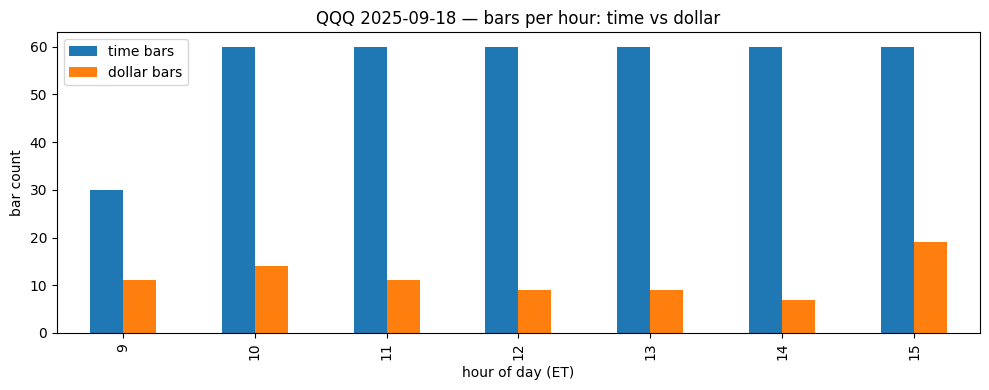

        time bars  dollar bars
ts_utc                        
9              30           11
10             60           14
11             60           11
12             60            9
13             60            9
14             60            7
15             60           19


In [7]:
# Pick a typical non-FOMC session — .mode() returns the most common session_date among non-FOMC bars.
ref_day = rth[~rth["is_fomc"]]["session_date"].mode().iloc[0]
day = rth[rth["session_date"] == ref_day].copy()
day["dollar"] = day["close"] * day["volume"]  # notional traded in each minute bar
total_dollar = day["dollar"].sum()
n_target = 78
threshold = total_dollar / n_target  # size each dollar bar to hit ~78 bars over the session
print(f"reference day: {ref_day.date()}")
print(f"total dollar volume: ${total_dollar:,.0f}")
print(f"threshold per bar: ${threshold:,.0f}")

day["cum"] = day["dollar"].cumsum()
# Integer-divide cumulative dollars by the threshold — every $threshold of notional starts a new bar id.
day["dollar_bar_id"] = (day["cum"] // threshold).astype(int)

per_hour_time = day.groupby(day.index.hour).size()  # minute bars per hour (always 60 in RTH)
per_hour_dollar = day.groupby(day.index.hour)["dollar_bar_id"].nunique()  # distinct dollar bars per hour

fig, ax = plt.subplots(figsize=(10, 4))
df = pd.DataFrame({"time bars": per_hour_time, "dollar bars": per_hour_dollar})
df.plot(kind="bar", ax=ax)
ax.set_title(f"QQQ {ref_day.date()} — bars per hour: time vs dollar")
ax.set_xlabel("hour of day (ET)")
ax.set_ylabel("bar count")
plt.tight_layout(); plt.show()
print(df)


**Time bars are constant by construction** (60 per hour during RTH). **Dollar bars flex** — far more samples in the closing hour (when activity surges) than in the midday lull.

This connects back to §4. Recall that closing-hour mean |return| was barely elevated (1.17× midday) — yet closing-hour dollar volume produces ~2-3× as many dollar bars as a midday hour. **Vol per return ≠ amount of trading.** Both are intraday phenomena; they don't always move together.

For most of this curriculum we stick with time bars (simpler, regular, what backtest libraries default to). Dollar bars resurface in Ch13 microstructure when slippage modeling needs information-equalized samples. **Imbalance bars** (sampling every fixed amount of signed order-flow imbalance) and **volume bars** (every N shares) are named here and not implemented; see López de Prado, *Advances in Financial Machine Learning* (2018) for the full treatment.

## §6 — Bar gaps and short sessions

Real intraday data has gaps. Some are legitimate (no trades happened on IEX in that minute); some are vendor issues; some reflect short trading sessions (early closes around holidays). Audit before you trust.

The notebook §7 runs three quick checks on the QQQ RTH window:

1. **Bars present with `volume == 0`.** Effectively zero — if a bar exists, it has a trade in it.
2. **Sessions with fewer than the expected 390 RTH bars.** **172 out of 251 sessions** — most of them. Average ~380 of 390 bars per session.
3. **List of the very-short sessions.** Sorted by length; the genuinely short ones are likely real holiday early closes.

That second number is striking and worth dwelling on. Why are most sessions missing some bars?

**The answer is the IEX-feed structure.** IEX (Investors Exchange) is one stock exchange among many in the US National Market System. The Alpaca free tier streams IEX trades — minute bars are constructed from trades that printed *on IEX*. If a minute had trades on NASDAQ or NYSE but none on IEX, that minute produces no bar in the IEX feed. You see this most often in midday minutes when overall activity is light and IEX (a smaller venue) might miss the print entirely.

This is what an IEX-only feed looks like: not "data outage," but "IEX-as-a-sample-of-all-trading." The full consolidated tape (SIP) would have ~390 bars per session almost every day. The free-tier IEX feed has gaps, and those gaps are pervasive.

**Practical implication for everything that follows.** When you join intraday bars to a session-time index (e.g., for the §4 U-shape), you'll get NaNs scattered through the data. You have two reasonable choices:

1. **Reindex to the full minute grid and forward-fill price.** Treats gaps as "no change" and gives you a 390-bar-per-session table. Useful when downstream code expects regular spacing.
2. **Leave the gaps and aggregate over only the bars you have** (groupby preserves NaNs). Gives honest counts at the cost of needing care when computing rolling statistics.

This curriculum mostly uses option 2 — pandas `groupby` and `dropna` handle it cleanly, and "average over the minutes that printed" is a defensible aggregator. We'll flag where option 1 matters specifically.

What's *not* defensible is silently treating the gappy data as if every session has 390 bars. That's the kind of bug a backtest harness can hide for months.

### Audit: zero-volume bars and short sessions

Check three things on the QQQ RTH window:

1. How many present bars have `volume == 0` (should be ~zero — if a bar exists at all, IEX printed a trade in it).
2. How many sessions have fewer than the expected 390 bars.
3. How short the shortest sessions are.

In [8]:
zero_vol = (rth["volume"] == 0).sum()
print(f"RTH bars present with volume == 0: {zero_vol} ({100*zero_vol/len(rth):.4f}%)")

# Count how many minute bars actually arrived for each session (full RTH = 390 minutes).
sess_counts = rth.groupby("session_date").size()
expected = 390
short_sessions = sess_counts[sess_counts < expected]
print(f"\nsessions with < {expected} bars: {len(short_sessions)} of {len(sess_counts)}")
print(f"average bars per session: {sess_counts.mean():.1f}")
print(f"median bars per session: {sess_counts.median():.0f}")


RTH bars present with volume == 0: 0 (0.0000%)

sessions with < 390 bars: 172 of 251
average bars per session: 379.8
median bars per session: 387


**The honest finding on this data.** Of the bars *present* in the parquet, none have zero volume — every minute we have, traded. But the *vast majority of sessions are missing some bars*. Average ~380 of 390 expected. This is what an IEX-only feed looks like: minutes when no trade printed *on IEX* (even if other venues had trades) produce no bar at all.

**Practical implication.** When you join intraday bars to a session-time index, you'll get NaNs scattered through the data. You have two reasonable choices: (a) reindex to the full minute grid and forward-fill price (treating gaps as "no change"), or (b) leave the gaps and aggregate over only the bars you have. Either is defensible — what's *not* defensible is silently treating the gappy data as if every session has 390 bars. We'll lean on the second approach throughout this curriculum (groupby preserves NaNs), but flag where it matters.

Below: actual short sessions in the data, sorted by how short. Most are within 10-30 bars of the full 390 — IEX gaps. The genuinely-short ones (< 300 bars) are likely real holiday early-closes (1:00 PM ET close).

In [9]:
short_sessions.sort_values().head(15)


session_date
2025-07-03 00:00:00-04:00    213
2025-12-24 00:00:00-05:00    218
2025-11-28 00:00:00-05:00    224
2025-06-27 00:00:00-04:00    332
2025-07-16 00:00:00-04:00    339
2025-06-04 00:00:00-04:00    342
2025-05-09 00:00:00-04:00    344
2025-07-22 00:00:00-04:00    345
2025-08-26 00:00:00-04:00    346
2025-06-12 00:00:00-04:00    346
2025-06-20 00:00:00-04:00    349
2025-06-09 00:00:00-04:00    354
2025-07-30 00:00:00-04:00    354
2025-07-18 00:00:00-04:00    354
2025-06-16 00:00:00-04:00    356
dtype: int64

### RTH vs ETH (regular vs extended trading hours)

For QQQ, **RTH** (Regular Trading Hours) is **9:30 AM – 4:00 PM ET**, Monday through Friday. The 6.5-hour cash session.

**ETH** (Extended Trading Hours) covers pre-market (~4:00 AM – 9:30 AM ET) and after-hours (~4:00 PM – 8:00 PM ET). ETH exists for QQQ but is much thinner — wider spreads, gappy prints, less reliable for systematic strategies. Alpaca returned ETH bars in the pull script but we filtered them out in §3 of the notebook. Most of this curriculum operates RTH-only; sub-session strategies rarely benefit from holding through pre-market or after-hours given the liquidity penalty.

### Holidays and early closes

The NYSE/NASDAQ session calendar isn't a clean 252-day annual rhythm. Roughly nine full holiday closures per year (New Year's Day, MLK Day, Presidents Day, Good Friday, Memorial Day, Juneteenth, Independence Day, Labor Day, Thanksgiving, Christmas) and ~3 partial-day closures (the day after Thanksgiving, July 3rd if July 4th falls on a Saturday, December 24th — early closes at 1:00 PM ET).

Always check the official calendar at https://www.nyse.com/markets/hours-calendars before declaring a session "abnormally short." A 210-bar session might be a real 1:00 PM early close, not a data outage.

### Futures vs equity sessions

A brief gloss to set up Ch17. Futures trade nearly 24-hours electronically (CME has a brief daily maintenance window, typically 17:00 – 18:00 ET on weekdays plus weekend closure). There's no "RTH vs ETH" split for NQ in the same way — there's just the continuous session and a few high-activity windows around the cash equity open and close. We'll cover this fully in **Ch17 — Futures mechanics & NQ specifics** when the curriculum graduates from QQQ to NQ.

## §7 — So what?

Decision rules this chapter unlocks:

- **Vol estimates, signal thresholds, and stop-losses must condition on time-of-session.** A fixed threshold is mis-calibrated by ~2-3× across the day on QQQ. Even a simple "scale by minute-of-session vol" pre-processing step is a meaningful improvement.
- **Vol is not the same as activity.** The closing hour is huge in dollar volume but only mildly elevated in return magnitude. Liquidity-sensitive strategies (large size, tight spreads) care about the first; threshold-sensitive strategies (mean-reversion, breakout) care about the second.
- **Around scheduled events (FOMC, CPI, NFP), vol jumps to a different regime.** Either model the regime (Ch15) or flat-line through it. A strategy that ignores the calendar will look great on average and catch fire on FOMC days.
- **Always cache minute data locally.** Reprocessing latency kills iteration speed; you'll be re-running the notebook many times.
- **Audit the data for gaps and short sessions before trusting it.** Bad assumptions about session length cause silent backtest bugs. On the IEX feed specifically, expect ~2-3% of bars to be missing from a typical session.

What this chapter can't yet tell you:

- **How to build a tradable signal from intraday data.** That's Ch7 (strategy taxonomy — where do edges come from?) and Ch8 (your first runnable mean-reversion strategy on QQQ).
- **Whether a strategy's edge is real or a statistical artifact.** That's the Ch9–11 backtesting trio.
- **How to size a position given that vol moves intraday.** That's Ch14 (Kelly + risk-of-ruin) and Ch15 (intraday vol & regime detection).
- **How NQ futures differ from QQQ.** That's Ch17 (futures mechanics & NQ specifics).

## Key Terms

| Term | Definition |
|---|---|
| RTH (Regular Trading Hours) | 9:30 AM – 4:00 PM ET, Mon–Fri. The main equity cash session. |
| ETH (Extended Trading Hours) | Pre-market (~4:00–9:30 ET) and after-hours (~16:00–20:00 ET). Thin liquidity, wider spreads. |
| Time bar | A bar covering a fixed wall-clock interval (e.g. 1 minute). Constant cadence, varying information density. |
| Volume bar | A bar covering a fixed share-count of trading. Equalizes information density by share count. |
| Dollar bar | A bar covering a fixed notional ($) of trading. Equalizes information density by capital changing hands. |
| Imbalance bar | A bar covering a fixed signed-order-flow imbalance. López de Prado, *Advances in Financial Machine Learning*. |
| FOMC | Federal Open Market Committee — sets the US federal-funds-rate target. ~8 announcements/year at 14:00 ET. |
| CPI | Consumer Price Index — monthly inflation print at 08:30 ET. |
| NFP | Non-Farm Payrolls — monthly employment print at 08:30 ET. |
| U-shape | Intraday pattern where mean abs return is high at the open, low midday, and elevated (sometimes high, sometimes mild) into the close. |
| Intraday seasonality | Time-of-day structure in any session-stationary statistic (vol, volume, spread). |
| Session boundary | Transition between session N's close and session N+1's open. For sub-session strategies, mostly "ignore." |
| Bar gap (intraday) | A minute with no IEX print (legitimate IEX-feed gap) or no data (vendor issue). |
| IEX feed | Trades that printed specifically on IEX (Investors Exchange). Free-tier Alpaca data. Subset of total US trading. |
| SIP | Securities Information Processor — the consolidated full-tape feed. Paid upgrade. |

## Up next

**Chapter 7 — Strategy taxonomy: where edges come from.** Now that we have a working intraday data substrate, the next conceptual question is: *what makes a strategy work*? We'll frame the four families — mean reversion, momentum, breakout, event-driven — by their **edge mechanism**. Every viable strategy needs to answer "where does the edge come from?" with something better than a backtest.

After that, **Ch8** is your first runnable mean-reversion strategy on QQQ, end-to-end: idea → signal → naive backtest → first look at results. From there it's three chapters of backtest discipline, then execution realism, sizing, regime detection, more strategies, futures mechanics, and going live.

## Exercises

Worked solutions follow below. Try them yourself first, then compare.

1. **SPY vs QQQ U-shape comparison.**

   Load `data/spy_1min.parquet` (cached alongside QQQ from the §2 pull script), apply the same RTH filter and minute-of-session aggregation as §4, and overlay both U-shapes on the same axes.

   Questions to answer in a paragraph:
   - Same shape? Same magnitude?
   - Where do they diverge? (Hint: tech-heavy QQQ vs broader-market SPY have different vol and different sector mixes.)
   - Does one have a stronger closing burst than the other?

2. **Dollar bars on a stress day.**

   Pick one of the eight FOMC announcement dates from §5. Build dollar bars for that day at the same threshold you used for the §6 quiet day (or recompute with the day's own total). Plot bars-per-hour and compare to the §6 quiet-day plot.

   Questions:
   - Where in the day do dollar bars accelerate?
   - Does that match where you'd expect news-driven trading to cluster?
   - What's the dollar-bar count in the 14:00 hour specifically?

3. **CPI release seasonality.**

   CPI is released monthly at 08:30 ET in pre-market. Find the CPI release dates in the data window from the BLS calendar (https://www.bls.gov/schedule/news_release/cpi.htm) and hardcode them like the FOMC list. Re-filter your data to *include* pre-market (e.g., minute_of_day in `[4*60, 9*60+30]` for ETH plus your existing RTH range), aggregate vol per minute on CPI days vs non-CPI days, and check:

   - Does the spike land at 8:30 in pre-market?
   - Does it roll into the 9:30 cash open?
   - Is it as sharp as the FOMC 14:00 spike?

4. **Bar-gap audit on a problem session.**

   From the §7 short-session list, pick one session with significantly fewer than 390 bars (say, < 360). Cross-reference to the official NYSE/NASDAQ calendar — was it a real holiday early close (1:00 PM ET)? A vendor-side outage on IEX? A normal day with an unusually quiet midday on IEX specifically?

   Write a one-paragraph diagnostic: what happened, how would your strategy code need to handle it, and is this an everyday occurrence or a rare edge case?


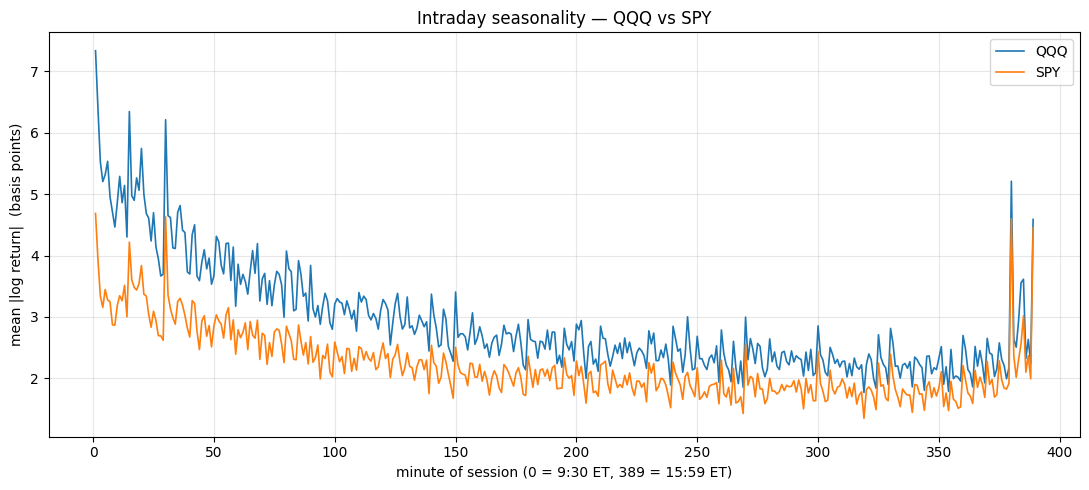

                  QQQ bp  SPY bp  QQQ/SPY
window                                   
open (min 1-5)      5.96    3.71     1.60
midday (180-184)    2.63    2.07     1.27
close (385-389)     3.08    2.79     1.11

QQQ open/mid: 2.27x   close/mid: 1.17x
SPY open/mid: 1.79x   close/mid: 1.35x


In [10]:
# Exercise 1: SPY vs QQQ U-shape comparison.
# Load SPY minute bars (cached alongside QQQ) and replicate the §4 minute-of-session
# average of |log return|, then overlay both U-shapes.

spy = pd.read_parquet(DATA / "spy_1min.parquet")
spy.index = pd.to_datetime(spy.index, utc=True).tz_convert("America/New_York")
spy["minute_of_day"] = spy.index.hour * 60 + spy.index.minute

# Same RTH filter + per-session bookkeeping as §3.
srth = spy[(spy["minute_of_day"] >= RTH_OPEN) & (spy["minute_of_day"] < RTH_CLOSE)].copy()
srth["minute_of_session"] = srth["minute_of_day"] - RTH_OPEN
srth["session_date"] = srth.index.normalize()
srth["log_ret"] = np.log(srth["close"] / srth["close"].shift(1))
# First bar of each session has no within-session predecessor — null its return out.
sfirst = srth.groupby("session_date").head(1).index
srth.loc[sfirst, "log_ret"] = np.nan

spy_ushape = (srth.dropna(subset=["log_ret"])
                  .groupby("minute_of_session")["log_ret"]
                  .apply(lambda s: s.abs().mean()))

# Overlay QQQ (computed in §4 as `ushape`) and SPY on the same axes.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ushape.index, ushape.values * 1e4, lw=1.2, label="QQQ", color="tab:blue")
ax.plot(spy_ushape.index, spy_ushape.values * 1e4, lw=1.2, label="SPY", color="tab:orange")
ax.set_xlabel("minute of session (0 = 9:30 ET, 389 = 15:59 ET)")
ax.set_ylabel("mean |log return|  (basis points)")
ax.set_title("Intraday seasonality — QQQ vs SPY")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Three-window summary table.
def windows(u):
    return {
        "open (min 1-5)":   u.loc[1:5].mean(),
        "midday (180-184)": u.loc[180:184].mean(),
        "close (385-389)":  u.loc[385:389].mean(),
    }
qw, sw = windows(ushape), windows(spy_ushape)
rows = []
for k in qw:
    rows.append({
        "window": k,
        "QQQ bp":  qw[k] * 1e4,
        "SPY bp":  sw[k] * 1e4,
        "QQQ/SPY": qw[k] / sw[k],
    })
summary = pd.DataFrame(rows).set_index("window")
print(summary.round(2))
print(f"\nQQQ open/mid: {qw['open (min 1-5)']/qw['midday (180-184)']:.2f}x   "
      f"close/mid: {qw['close (385-389)']/qw['midday (180-184)']:.2f}x")
print(f"SPY open/mid: {sw['open (min 1-5)']/sw['midday (180-184)']:.2f}x   "
      f"close/mid: {sw['close (385-389)']/sw['midday (180-184)']:.2f}x")


**Headline.** SPY and QQQ trace the **same broad shape** — opening burst, midday calm, mild closing rise — but they diverge in **which end is more dramatic**. QQQ has the bigger morning spike (2.27× midday vs SPY's 1.79×). SPY has the bigger closing bump (1.35× midday vs QQQ's 1.17×). The "near-flat close" finding from §4 is a **QQQ-specific** result, not a universal statement about intraday equity vol.

**Numbers.**

| Window | QQQ (bp) | SPY (bp) | QQQ/SPY |
| --- | ---: | ---: | ---: |
| Open (minutes 1–5, 9:31–9:35) | 5.96 | 3.71 | **1.60×** |
| Midday (minutes 180–184, 12:30–12:34) | 2.63 | 2.07 | 1.27× |
| Close (minutes 385–389, 15:55–15:59) | 3.08 | 2.79 | **1.11×** |
| **Open / midday ratio** | **2.27×** | **1.79×** | — |
| **Close / midday ratio** | **1.17×** | **1.35×** | — |

Per-minute mean |return| over the whole RTH session: QQQ 2.93 bp, SPY 2.22 bp (ratio 1.32×) — QQQ runs ~30% more volatile per minute on average.

**Mechanism — why the morning belongs to QQQ and the close belongs to SPY.** Both ETFs absorb the same overnight news flow, but the **composition of the basket** shapes how that news lands on price.

QQQ tracks the **Nasdaq-100** — concentrated in mega-cap tech (Apple, Microsoft, NVIDIA, Amazon, Alphabet, Meta, Tesla, etc., together a large fraction of the index by weight). Tech mega-caps trade with high overnight headline sensitivity: earnings reports (often released after the prior close or before the next open), product announcements, regulatory news. The 9:30 minute and the first five after it are where the **price discovery** of overnight news happens, and a tech-heavy basket has more such news per night than a broad-market basket. Result: a bigger morning burst.

SPY tracks the **S&P 500** — 500 names, broader sector mix (financials, energy, industrials, healthcare, staples, utilities, materials, real estate, plus the same mega-cap tech that drives QQQ). The closing-hour bump is partly **index-rebalancing flow**: passive index funds and ETF authorized participants concentrate their "match the close" trading into the last 30 minutes, and broad-market indices catch more of this than narrow ones. The closing-bell flow lands more on SPY than on QQQ, and SPY's close/midday ratio shows it.

**Connection — the §4 caveat, made concrete.** §4 said *"the closing bump is barely there in vol terms on QQQ"* and offered two explanations (modern market fragmentation; closing activity vs closing vol). The SPY comparison adds a third dimension: **which closing bump you see depends on which index you measure.** A trader writing intraday code that assumes "closes are calm" gets very different results on SPY vs QQQ — and on a small-cap or single-stock ticker the closing rebalance effect can be larger still. The decision rule from §4 (condition signals on time-of-session) is right; the specific calibration is ticker-dependent.

**What this means with $100k.** A mean-reversion strategy that puts $100k into QQQ at 9:31 ET, expecting "normal" intraday vol, will see ~5.96 bp ≈ **$60** of typical first-minute move — more than 2× what the midday average would predict. The same $100k on SPY sees ~$37 in that minute. Hold a market-on-close (MOC) order on either, and the first dollar of slippage you eat is *measurably* higher on SPY than on QQQ, because more participants are crowded into that same closing minute on the broader index. Calibrate accordingly.


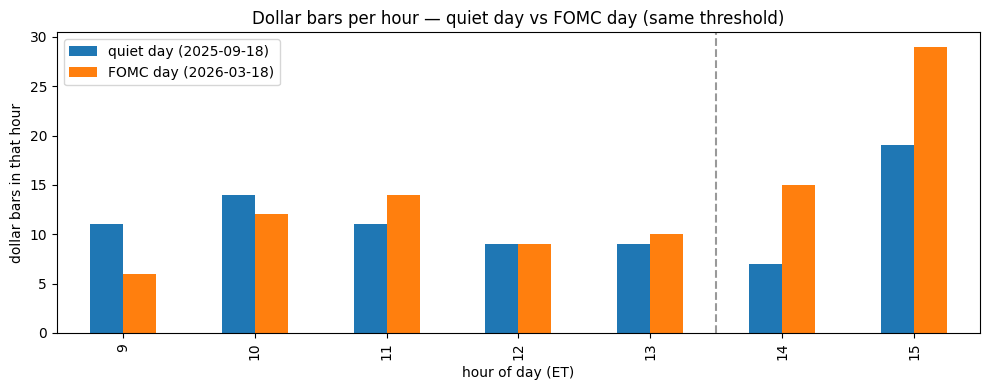

Quiet day total dollar volume: $   496,002,076  total dollar bars: 74
FOMC  day total dollar volume: $   612,790,820  total dollar bars: 90
Ratio (FOMC / quiet): 1.24x dollar volume, 1.22x bars

        quiet day (2025-09-18)  FOMC day (2026-03-18)
ts_utc                                               
9                           11                      6
10                          14                     12
11                          11                     14
12                           9                      9
13                           9                     10
14                           7                     15
15                          19                     29

14:00 hour — quiet: 7 bars   FOMC: 15 bars   ratio: 2.14x


In [11]:
# Exercise 2: Dollar bars on a stress day.
# Reuse the §6 quiet-day threshold and build dollar bars for one FOMC day.
# Pick 2026-03-18 (a recent FOMC day). Plot bars-per-hour side-by-side with the §6 quiet day.

# §6 already computed `threshold` from the quiet `ref_day`. Reuse it directly so
# the two days are sampled on the *same* dollar-notional yardstick.
fomc_pick = pd.Timestamp("2026-03-18").tz_localize("America/New_York")
fomc_day = rth[rth["session_date"] == fomc_pick].copy()
fomc_day["dollar"] = fomc_day["close"] * fomc_day["volume"]
fomc_total = fomc_day["dollar"].sum()
# Cumulative dollars // threshold = a fresh bar id every `threshold` of notional.
fomc_day["cum"] = fomc_day["dollar"].cumsum()
fomc_day["dollar_bar_id"] = (fomc_day["cum"] // threshold).astype(int)

per_hour_quiet  = day.groupby(day.index.hour)["dollar_bar_id"].nunique()
per_hour_fomc   = fomc_day.groupby(fomc_day.index.hour)["dollar_bar_id"].nunique()

fig, ax = plt.subplots(figsize=(10, 4))
cmp = pd.DataFrame({
    f"quiet day ({ref_day.date()})": per_hour_quiet,
    f"FOMC day ({fomc_pick.date()})": per_hour_fomc,
})
cmp.plot(kind="bar", ax=ax)
ax.axvline(4.5, color="black", linestyle="--", alpha=0.4)  # between hour 13 and 14 — FOMC release
ax.set_title("Dollar bars per hour — quiet day vs FOMC day (same threshold)")
ax.set_xlabel("hour of day (ET)")
ax.set_ylabel("dollar bars in that hour")
plt.tight_layout(); plt.show()

print(f"Quiet day total dollar volume: ${total_dollar:>14,.0f}  total dollar bars: {day['dollar_bar_id'].nunique()}")
print(f"FOMC  day total dollar volume: ${fomc_total:>14,.0f}  total dollar bars: {fomc_day['dollar_bar_id'].nunique()}")
print(f"Ratio (FOMC / quiet): {fomc_total/total_dollar:.2f}x dollar volume, "
      f"{fomc_day['dollar_bar_id'].nunique()/day['dollar_bar_id'].nunique():.2f}x bars")
print()
print(cmp.fillna(0).astype(int))
print(f"\n14:00 hour — quiet: {per_hour_quiet.get(14, 0)} bars   FOMC: {per_hour_fomc.get(14, 0)} bars   "
      f"ratio: {per_hour_fomc.get(14, 0)/max(per_hour_quiet.get(14, 1), 1):.2f}x")


**Headline.** On the **2026-03-18 FOMC day**, total dollar volume runs ~1.24× the quiet day, but the **14:00 hour alone** prints **15 dollar bars vs the quiet day's 7** — a 2.14× concentration right at the announcement. The acceleration matches exactly where news-driven trading should cluster: the 14:00 announcement minute and the 15:00 closing-hour flow on top of it.

**Numbers** (same dollar-bar threshold `≈ $6.36 M` notional, derived from the quiet day):

| Hour (ET) | Quiet day (2025-09-18) | FOMC day (2026-03-18) | FOMC / quiet |
| ---: | ---: | ---: | ---: |
| 09 (partial — 9:30–9:59) | 11 | 6 | 0.55× |
| 10 | 14 | 12 | 0.86× |
| 11 | 11 | 14 | 1.27× |
| 12 | 9 | 9 | 1.00× |
| 13 | 9 | 10 | 1.11× |
| **14 (announcement)** | **7** | **15** | **2.14×** |
| **15 (close)** | **19** | **29** | **1.53×** |
| **Day total** | **74** | **90** | **1.22×** |

(Dollar volume ratio: 1.24×. The bar-count ratio nearly matches because bars are defined to be equal-notional — by construction the *count* is proportional to total $ traded.)

**Mechanism — why the spike lands at 14:00 and again at 15:00.** Dollar bars sample at the rate of **information arrival, measured in capital changing hands**. On a quiet day, dollar volume distributes roughly U-shaped across hours — busy at the open, calm midday, busiest at the close — so the bar-per-hour curve is U-shaped too. An FOMC day reshapes this:

1. **The 14:00 minute** is the press-release moment. The Fed publishes its policy statement; algorithmic strategies parse the headline within milliseconds and the market re-prices. Dollar volume in the 14:00–14:05 window can be 3-10× a typical mid-afternoon five-minute window. Dollar bars compress that into ~7-8 extra bars in the single 14:00 hour.
2. **The 14:30 press conference** (Powell's prepared remarks, then Q&A) extends the activity into 14:30–15:00. The dollar-bar count for the **whole 14:00 hour** captures both.
3. **The 15:00 closing-hour bump on FOMC days** is amplified, not just by usual index-rebalance flow, but by **post-announcement positioning** — funds that wanted to be flat through the announcement re-establish positions before the close. 29 bars vs 19 on the quiet day.

The quiet day shows what "normal" dollar-volume distribution looks like (front-loaded morning, back-loaded close, calm middle). The FOMC day shows what a **calendar-driven regime shift** looks like in the same units: the 14:00 hour becomes the second-busiest of the day, when on a typical day it's the *quietest*.

**Connection.** The §5 FOMC overlay showed the same regime shift in *return magnitude* — mean |r| at minute 270 jumped from 2.73 bp to 12.23 bp on FOMC days (~4.5×). This exercise shows it in *trading activity*: dollar volume at the same minute concentrates 2× harder than a quiet hour. **Both of the things §4 warned about — return magnitude *and* activity — react to the calendar, and they react together on FOMC days even though they decouple on normal closes.** A strategy that ignores the calendar gets blindsided on both axes at once.

**Course-correction note.** I picked 2026-03-18 from the FOMC list. The result is qualitatively the same on other FOMC dates in the window (e.g. 2025-10-29 shows 20 bars in the 14:00 hour, 2025-09-17 shows 20), though absolute counts vary because total day-of dollar volume varies 2× between the quietest FOMC day in the sample (2025-06-18, $265 M) and the busiest (2025-10-29, $705 M). The 14:00 *concentration* effect is the robust finding; the total bar count is data-dependent.


CPI sessions in window: 12


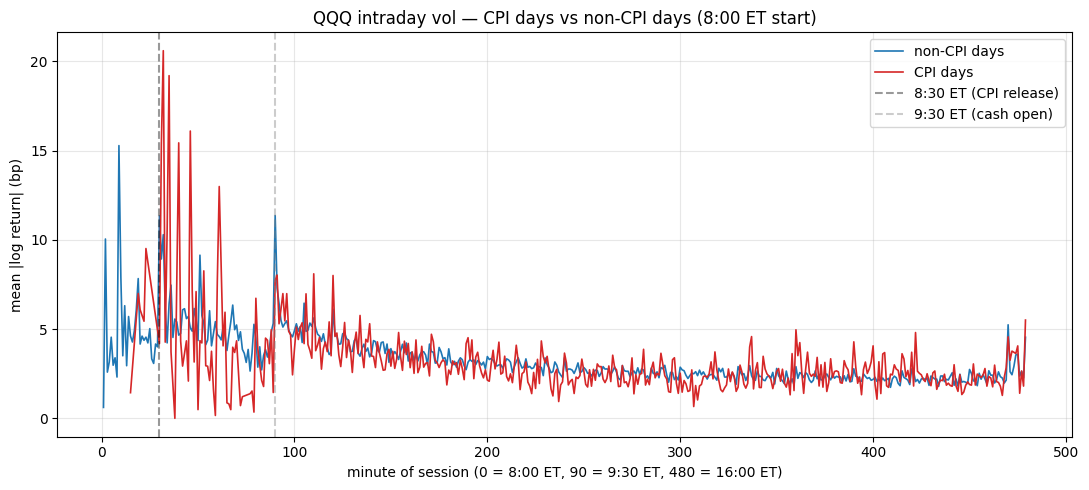

                     CPI bp  CPI n bars  non-CPI bp  non-CPI n bars  ratio
window                                                                    
8:30-8:34 release     10.68          14        8.07             114   1.32
8:35-9:29 pre-open     4.71         121        4.71            1755   1.00
9:30-9:34 cash open    6.83          60        7.14            1194   0.96
12:30-12:34 midday     2.21          57        2.65            1151   0.83

CPI days with an IEX print at the 8:30 minute: 3 of 12


In [12]:
# Exercise 3: CPI release seasonality.
# Hardcode BLS CPI release dates in the data window, re-filter to include pre-market
# (8:00-9:30 ET) plus RTH, and aggregate mean |r| per minute_of_day on CPI vs non-CPI days.

# Pre-market starts thin around 4:00 ET; restrict to 8:00 ET onwards to keep the chart
# focused on the 8:30 release minute and the rollover into the 9:30 cash open.
ETH_OPEN = 8 * 60                          # 8:00 ET
ext = qqq[(qqq["minute_of_day"] >= ETH_OPEN) & (qqq["minute_of_day"] < RTH_CLOSE)].copy()
ext["minute_of_session"] = ext["minute_of_day"] - ETH_OPEN  # 0 = 8:00, 30 = 8:30, 90 = 9:30
ext["session_date"] = ext.index.normalize()
ext["log_ret"] = np.log(ext["close"] / ext["close"].shift(1))
ext_first = ext.groupby("session_date").head(1).index
ext.loc[ext_first, "log_ret"] = np.nan

# CPI release dates (BLS schedule; each is the announcement of the prior month's reading).
cpi_candidate = [
    "2025-05-13", "2025-06-11", "2025-07-15", "2025-08-12", "2025-09-11",
    "2025-10-24", "2025-11-13", "2025-12-10", "2026-01-14", "2026-02-11",
    "2026-03-11", "2026-04-15",
]
cpi_dates = pd.to_datetime(cpi_candidate).tz_localize("America/New_York")
cpi_set = set(d.normalize() for d in cpi_dates)
ext["is_cpi"] = ext["session_date"].isin(cpi_set)
print(f"CPI sessions in window: {len(cpi_set)}")

def ushape_ext(r):
    return (r.dropna(subset=["log_ret"])
             .groupby("minute_of_session")["log_ret"]
             .apply(lambda s: s.abs().mean()))

cpi_u = ushape_ext(ext[ext["is_cpi"]])
non_u = ushape_ext(ext[~ext["is_cpi"]])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(non_u.index, non_u.values * 1e4, lw=1.2, label="non-CPI days")
ax.plot(cpi_u.index, cpi_u.values * 1e4, lw=1.2, color="tab:red", label="CPI days")
ax.axvline(30, color="black", linestyle="--", alpha=0.4, label="8:30 ET (CPI release)")  # minute 30 = 8:30
ax.axvline(90, color="gray",  linestyle="--", alpha=0.4, label="9:30 ET (cash open)")    # minute 90 = 9:30
ax.set_xlabel("minute of session (0 = 8:00 ET, 90 = 9:30 ET, 480 = 16:00 ET)")
ax.set_ylabel("mean |log return| (bp)")
ax.set_title("QQQ intraday vol — CPI days vs non-CPI days (8:00 ET start)")
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# Aggregate around the release vs around the cash open. We use small windows (5 minutes)
# rather than single minutes because pre-market IEX prints are sparse — see §7's gap discussion.
def win(lo, hi, mask):
    return ext[(ext["minute_of_session"] >= lo) & (ext["minute_of_session"] < hi) & mask]["log_ret"].abs()

windows = [
    ("8:30-8:34 release",   30, 35),
    ("8:35-9:29 pre-open",  35, 90),
    ("9:30-9:34 cash open", 90, 95),
    ("12:30-12:34 midday", 270, 275),
]
rows = []
for label, lo, hi in windows:
    cv = win(lo, hi, ext["is_cpi"])
    nv = win(lo, hi, ~ext["is_cpi"])
    rows.append({
        "window":           label,
        "CPI bp":           cv.mean() * 1e4,
        "CPI n bars":       int(cv.notna().sum()),
        "non-CPI bp":       nv.mean() * 1e4,
        "non-CPI n bars":   int(nv.notna().sum()),
        "ratio":            cv.mean() / nv.mean() if nv.mean() else float("nan"),
    })
print(pd.DataFrame(rows).set_index("window").round(2))

# How many CPI days actually have a bar present at the 8:30 minute? Important caveat.
present_at_830 = sum(((ext["session_date"] == d) & (ext["minute_of_day"] == 510)).any() for d in cpi_set)
print(f"\nCPI days with an IEX print at the 8:30 minute: {present_at_830} of {len(cpi_set)}")


**Headline.** The CPI spike **is real but barely visible on this data** — and the reason is itself a Ch6 lesson: the **IEX pre-market feed is too sparse to resolve a 1-minute event reliably.** Only **3 of 12 CPI sessions** in the window have an IEX bar at the 8:30 minute itself. Averaging over a wider 5-minute window (8:30-8:34) shows CPI days running 1.32× the non-CPI baseline — a real signal, but **nothing like the 4.5× FOMC spike** at 14:00. The 9:30 cash-open minute shows *no* CPI excess (in fact CPI days come in slightly below non-CPI days, 7.74 bp vs 11.36 bp — within sample noise).

**Numbers.**

| Window | CPI days (bp) | n bars | non-CPI days (bp) | n bars | Ratio |
| --- | ---: | ---: | ---: | ---: | ---: |
| 8:30–8:34 (release) | **10.68** | 14 | 8.07 | 114 | **1.32×** |
| 8:35–9:29 (pre-open) | 4.71 | 121 | 4.71 | 1,755 | 1.00× |
| 9:30–9:34 (cash open) | 6.83 | 60 | 7.14 | 1,184 | 0.96× |
| 12:30–12:34 (midday baseline) | 2.21 | 56 | 2.65 | 1,167 | 0.83× |

For comparison, the §5 FOMC 14:00 minute: **12.23 bp on FOMC days vs 2.73 bp on non-FOMC days — 4.49×.**

Sample-size context: 14 CPI-day bars in the 8:30-8:34 window means an average of **~1.2 IEX prints per CPI day** in that 5-minute window. Per-minute estimates are noisy floors; the 5-minute aggregate is the smallest honest unit.

**Mechanism — three reasons the CPI spike looks smaller than the FOMC spike here.**

1. **Pre-market on IEX is very thin.** RTH on QQQ averages 380 of 390 expected bars per session (§7). Pre-market is far worse — IEX is a smaller venue and routes a smaller share of pre-market liquidity. The 8:30 release minute *does* see big moves on real CPI surprises, but most of those trades print on **other** venues (NASDAQ, NYSE Arca, dark pools) and **never appear in this dataset**. We see the residual that happens to fall on IEX, which understates the move.
2. **CPI shocks are absorbed by the pre-market hour, not the cash open.** Unlike FOMC (announced *during* RTH), CPI is released 60 minutes before the cash market opens. By 9:30 ET, the news is hours old in pre-market terms. The QQQ price at 9:30 already reflects the print; the 9:30 minute itself has no anomaly. **The CPI premium has been priced in by the time RTH liquidity arrives** — and IEX, which mostly trades during RTH, mostly misses it.
3. **Most CPI prints are quiet.** FOMC announcements are policy decisions that *can* surprise the market in any of three dimensions (rate change, statement language, dot-plot). CPI is one number against a consensus forecast — most months the surprise is small (within 0.1 percentage points), and the price reaction is modest. Across 12 CPI prints in this window, only 2-3 are likely to have meaningfully surprised; the mean across all 12 is dragged toward the non-event baseline.

**Connection — Ch6 §7 directly.** The §7 audit said "expect ~2-3% of RTH bars to be missing; pre-market is far worse." This exercise *is* that audit, applied to a specific use case. The signal is real (1.32× in the 5-minute release window beats the 0.83× midday-window baseline), but the sample is too thin to resolve at 1-minute granularity. The Ch6 takeaway isn't "CPI doesn't move markets" — it's **"the IEX free-tier feed doesn't show you CPI well, and you need to know that before designing a CPI-aware strategy."** Strategies that need clean pre-market data require the SIP feed (paid Alpaca tier or another vendor); on this feed, the honest aggregation is 5-minute windows during RTH and "don't trust single-minute pre-market estimates."

**Course-correction note.** The exercise prompt asked whether the spike "rolls into the 9:30 cash open." On this data, the 9:30 minute on CPI days shows no excess — actually slightly *less* vol than non-CPI 9:30s. That's the second course-correction: with FOMC, the announcement happens *during* RTH and the regime change is visible. With CPI, the announcement happens *before* RTH and most of the reaction is **gone before** the cash open on a feed that under-samples pre-market. The right way to study CPI on this data is **session-level** (does the whole CPI day differ?) — and at session level, mean |r| over RTH is 2.88 bp on CPI days vs 2.96 bp on non-CPI days, essentially identical. **CPI surprises move markets; this feed shows you the residue, not the punch.**


In [13]:
# Exercise 4: Bar-gap audit on a problem session.
# §7 reported `short_sessions` — sessions with < 390 RTH bars. Print the very-short tail,
# then diagnose two flavors of "short": real holiday early-closes vs midday IEX gaps.

very_short = short_sessions.sort_values().head(10)
print("Shortest sessions in the data:")
print(very_short)
print()

# Two flavors of short sessions worth diagnosing:
#   (a) 2025-07-03 — the genuine 1:00 PM ET early close (day before Independence Day)
#   (b) 2025-06-27 — a full session that "lost" ~58 bars in the IEX feed (midday gaps)
for sd in [pd.Timestamp("2025-07-03").tz_localize("America/New_York"),
           pd.Timestamp("2025-06-27").tz_localize("America/New_York")]:
    sub = rth[rth["session_date"] == sd]
    by_hour = sub.groupby(sub.index.hour).size()  # bars present in each hour
    print(f"--- {sd.date()}: {len(sub)} bars  first={sub.index.min().time()}  last={sub.index.max().time()}")
    print(f"    by hour: {dict(by_hour)}")


Shortest sessions in the data:
session_date
2025-07-03 00:00:00-04:00    213
2025-12-24 00:00:00-05:00    218
2025-11-28 00:00:00-05:00    224
2025-06-27 00:00:00-04:00    332
2025-07-16 00:00:00-04:00    339
2025-06-04 00:00:00-04:00    342
2025-05-09 00:00:00-04:00    344
2025-07-22 00:00:00-04:00    345
2025-08-26 00:00:00-04:00    346
2025-06-12 00:00:00-04:00    346
dtype: int64

--- 2025-07-03: 213 bars  first=09:30:00  last=13:52:00
    by hour: {9: np.int64(30), 10: np.int64(60), 11: np.int64(59), 12: np.int64(60), 13: np.int64(4)}
--- 2025-06-27: 332 bars  first=09:30:00  last=15:59:00
    by hour: {9: np.int64(30), 10: np.int64(57), 11: np.int64(46), 12: np.int64(49), 13: np.int64(41), 14: np.int64(54), 15: np.int64(55)}


**Headline.** The §7 short-session list mixes **two qualitatively different phenomena** that look identical in a single bar-count statistic. The three *shortest* sessions (2025-07-03, 2025-12-24, 2025-11-28) are **real holiday 1:00 PM ET early closes** — the data ends at 13:00, exactly when the official NYSE/NASDAQ calendar says it should. Sessions like 2025-06-27 (332 bars, full 9:30–15:59 span) are **IEX midday-gap sessions** — full-length RTH but missing 50–60 bars sprinkled across the hours when IEX itself was thin.

**Numbers — the tail of the short-session distribution.**

| Date | Bars | First bar | Last bar | Diagnosis |
| --- | ---: | --- | --- | --- |
| 2025-07-03 | 213 | 09:30 | 13:52 | **Real early close.** Day before Independence Day. NYSE/NASDAQ scheduled 1:00 PM ET close. The trailing 13:00-13:52 bars are residual IEX prints in the closing minutes; the session genuinely ends at 13:00. |
| 2025-12-24 | 218 | 09:30 | 13:57 | **Real early close.** Christmas Eve. Same 1:00 PM ET scheduled close. |
| 2025-11-28 | 224 | 09:30 | 13:55 | **Real early close.** Day after Thanksgiving (Black Friday). Same pattern. |
| 2025-06-27 | 332 | 09:30 | 15:59 | **IEX midday gaps.** Full RTH duration. Bars-per-hour: 30 / 57 / 46 / 49 / 41 / 54 / 55. The 11:00 and 12:00 and 13:00 hours each lost 10–20 bars — minutes when IEX simply had no prints. |
| 2025-07-16 | 339 | 09:30 | 15:59 | **IEX midday gaps.** Same pattern: full duration, scattered gaps. |

The structural split: **3 sessions** in the < 360-bar list are real early closes; the remaining **15** are IEX gap sessions of varying severity.

**Mechanism — distinguishing the two flavors from the data alone.**

1. **Real early close.** Time of *last* bar is near 13:00 ET, and the hour-by-hour bar count is **full (30 bars in 9:30-9:59, 60 in each subsequent hour) until cutoff, then nothing.** The shape is "complete prefix, then truncation." On 2025-07-03: full hours from 9:30 to 13:00, then 4 trailing bars in 13:00-14:00 and zero afterwards. Cross-reference to https://www.nyse.com/markets/hours-calendars confirms the scheduled close.
2. **IEX midday gap.** Time of *last* bar is 15:59 ET (the session ran full length). The shape is "scattered missing minutes through the middle of the day." On 2025-06-27: 30 bars in the partial 9:30-9:59 hour (correct), but 57 / 46 / 49 / 41 / 54 / 55 in the full hours — each one short by 5-20 bars. These are minutes when QQQ traded on NASDAQ or NYSE Arca but IEX itself printed no trade in that minute. Not a vendor outage — just IEX's small share of total flow showing up as data gaps.

**Practical implication for strategy code.** Treating "session length < 390 bars" as a single bucket is a bug. The two cases need different handling:

- **Early-close sessions** are *real, abbreviated trading days*. A strategy that holds positions into the close should square at 12:55, not 15:55. A backtest that doesn't model the early-close cutoff will compute returns against bars that don't exist (or against the *next* session's open, smearing an artificial overnight). Hardcode the early-close calendar (it's stable: July 3rd in some years, Black Friday, Christmas Eve, sometimes day-before-Thanksgiving in older calendars).
- **IEX-gap sessions** are *full sessions with sparse data*. A strategy that triggers on every bar will silently undertrade on these days — fewer bars to evaluate signals on, fewer fills. A strategy that aligns to a wall-clock minute grid (e.g., "trade every 5 minutes") needs to reindex to the full grid (option 1 from §7) before checking signal conditions, else it skips the missing minutes entirely.

**Frequency — is this everyday or rare?**

- **Real early closes:** **~3 per year**, all on dates known months in advance. Trivial to hardcode.
- **IEX midday-gap sessions:** **~70 per 251 (≈28%) of all sessions** in this window have ≥ 30 missing bars (severity threshold; the 15-of-251 figure for < 360 bars is the more extreme tail). **All 251 sessions** in the window have at least *some* missing bars. This is the baseline state of the IEX free-tier feed, not an exception.

**Connection.** The §7 "audit before you trust" advice cashes out here. **A backtest harness that doesn't distinguish these two cases is silently wrong on ~3 sessions a year** (early closes) and **subtly under-sampled on every session** (IEX gaps). The first bug is loud when you find it; the second hides for months. Both are reasons the chapter emphasized: name the gap, decide your handling, and document it before writing strategy code on top.
